# Statistical Analysis of Air Quality Data

This notebook analyzes the cleaned air quality dataset to understand patterns and relationships in air pollutants across different cities and AQI categories. We'll use various statistical tests to validate our assumptions and identify key relationships in the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, f_oneway, chi2_contingency, zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Load the Dataset

Let's start by loading the cleaned air quality dataset and checking its structure.

In [2]:
# Load the cleaned air quality dataset
df = pd.read_csv('../Data/processed/clean_data.csv')

# Check basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (17472, 16)

First few rows:
                  date              city  Latitude  Longitude  PM2.5  PM10  \
0  2025-11-08 00:00:00  Lahore, Pakistan   31.5497    74.3436   81.0  82.7   
1  2025-11-08 01:00:00  Lahore, Pakistan   31.5497    74.3436   78.2  79.6   
2  2025-11-08 02:00:00  Lahore, Pakistan   31.5497    74.3436   75.4  76.8   
3  2025-11-08 03:00:00  Lahore, Pakistan   31.5497    74.3436   72.2  73.6   
4  2025-11-08 04:00:00  Lahore, Pakistan   31.5497    74.3436   69.8  71.2   

    NO2   SO2      CO  Ozone  Aerosol_Optical_Depth AQI_category  year  month  \
0  94.0  16.4  1910.0   11.0                   0.19    Unhealthy  2025     11   
1  90.9  14.4  1413.0   10.0                   0.19    Unhealthy  2025     11   
2  85.0  12.8  1060.0   12.0                   0.19    Unhealthy  2025     11   
3  72.8  11.8   863.0   20.0                   0.19    Unhealthy  2025     11   
4  57.7  11.1   811.0   31.0                   0.19    Unhealthy  2025     11   



## Step 2: Descriptive Statistics

Descriptive statistics helps us understand the basic characteristics of our data. Let's look at:
- **Mean**: Average value of each pollutant
- **Standard Deviation**: How spread out the values are from the mean
- **Min/Max**: Range of values
- **Quartiles**: How data is distributed across 25%, 50%, 75% marks

In [3]:
# Select numerical columns for analysis
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

# Get descriptive statistics
desc_stats = df[pollutants].describe()
print("Statistical Summary of Air Quality Pollutants:")
print(desc_stats)
print("\n" + "="*80)

# Additional statistics
print("\nSkewness (how asymmetric the distribution is):")
print(df[pollutants].skew())
print("\nKurtosis (how peaked or flat the distribution is):")
print(df[pollutants].kurtosis())

Statistical Summary of Air Quality Pollutants:
              PM2.5          PM10           NO2           SO2            CO  \
count  17472.000000  17472.000000  17472.000000  17472.000000  17472.000000   
mean      66.060611     69.263124     38.458871     30.292691   1264.659741   
std       65.414505     66.576392     26.977070     41.777128   1484.401277   
min        0.300000      0.400000      0.000000      0.000000      0.000000   
25%       13.175000     14.800000     17.700000      6.100000    278.000000   
50%       45.500000     48.900000     31.800000     14.400000    713.000000   
75%       99.700000    104.300000     53.600000     37.900000   1627.000000   
max      430.300000    434.000000    185.100000    439.300000  13039.000000   

              Ozone  
count  17472.000000  
mean      54.746337  
std       49.928268  
min        0.000000  
25%       16.000000  
50%       45.000000  
75%       71.000000  
max      288.000000  


Skewness (how asymmetric the distribution

## Step 3: Normality Test (Shapiro-Wilk Test)

The Shapiro-Wilk test checks if our data follows a normal (bell-curve) distribution.

**Why it matters:** Many statistical tests assume data is normally distributed. If data isn't normal, we may need different statistical approaches.

**How to interpret:**
- **p-value > 0.05**: Data is likely normal (we fail to reject normality)
- **p-value ≤ 0.05**: Data is likely NOT normal (we reject normality)

In [4]:
# Perform Shapiro-Wilk test on PM2.5
pm25_data = df['PM2.5'].dropna()
statistic, p_value = shapiro(pm25_data)

print("Shapiro-Wilk Test Results for PM2.5:")
print(f"Test Statistic: {statistic:.6f}")
print(f"P-value: {p_value:.6f}")
print("\nInterpretation:")
if p_value > 0.05:
    print(f"P-value ({p_value:.6f}) > 0.05")
    print("✓ PM2.5 data appears to be normally distributed")
else:
    print(f"P-value ({p_value:.6f}) ≤ 0.05")
    print("✗ PM2.5 data does NOT appear to be normally distributed")
    print("This means the distribution is skewed or has heavy tails")

Shapiro-Wilk Test Results for PM2.5:
Test Statistic: 0.849470
P-value: 0.000000

Interpretation:
P-value (0.000000) ≤ 0.05
✗ PM2.5 data does NOT appear to be normally distributed
This means the distribution is skewed or has heavy tails


## Step 4: Z-Test for Comparing Two Groups

The Z-test compares the average PM2.5 levels between two different AQI categories to see if the difference is statistically significant (not just by chance).

**Why we use Z-test:**
- Large sample sizes (generally > 30)
- Population standard deviation is known or estimated
- Comparing means between two independent groups

**Interpretation:**
- **p-value > 0.05**: No significant difference between groups
- **p-value ≤ 0.05**: Significant difference between groups

In [5]:
# Check unique AQI categories
print("Available AQI categories:")
print(df['AQI_category'].unique())
print(f"\nValue counts:")
print(df['AQI_category'].value_counts())

# Select two groups for comparison - let's pick the two with most data
# For example, 'Good' and 'Unhealthy' or whatever your data has
group1_name = df['AQI_category'].value_counts().index[0]
group2_name = df['AQI_category'].value_counts().index[1]

group1 = df[df['AQI_category'] == group1_name]['PM2.5'].dropna()
group2 = df[df['AQI_category'] == group2_name]['PM2.5'].dropna()

print(f"\n\nComparing PM2.5 between '{group1_name}' and '{group2_name}'")
print(f"Group '{group1_name}': n={len(group1)}, mean={group1.mean():.3f}, std={group1.std():.3f}")
print(f"Group '{group2_name}': n={len(group2)}, mean={group2.mean():.3f}, std={group2.std():.3f}")

# Calculate Z-test manually
mean1 = group1.mean()
mean2 = group2.mean()
std1 = group1.std()
std2 = group2.std()
n1 = len(group1)
n2 = len(group2)

# Standard error of the difference
se_diff = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Z-statistic
z_stat = (mean1 - mean2) / se_diff

# Two-tailed p-value
p_value_ztest = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\nZ-Test Results:")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (two-tailed): {p_value_ztest:.6f}")
print("\nInterpretation:")
if p_value_ztest <= 0.05:
    print(f"✓ P-value ({p_value_ztest:.6f}) ≤ 0.05")
    print(f"There IS a statistically significant difference in PM2.5 levels")
    print(f"between '{group1_name}' and '{group2_name}' categories.")
else:
    print(f"✗ P-value ({p_value_ztest:.6f}) > 0.05")
    print(f"There is NO statistically significant difference in PM2.5 levels")
    print(f"between '{group1_name}' and '{group2_name}' categories.")

Available AQI categories:
['Unhealthy' 'Unhealthy for Sensitive' 'Moderate' 'Hazardous' 'Good']

Value counts:
AQI_category
Unhealthy                  5970
Good                       4032
Moderate                   3829
Hazardous                  1991
Unhealthy for Sensitive    1650
Name: count, dtype: int64


Comparing PM2.5 between 'Unhealthy' and 'Good'
Group 'Unhealthy': n=5970, mean=94.158, std=25.798
Group 'Good': n=4032, mean=6.904, std=2.756

Z-Test Results:
Z-statistic: 259.1475
P-value (two-tailed): 0.000000

Interpretation:
✓ P-value (0.000000) ≤ 0.05
There IS a statistically significant difference in PM2.5 levels
between 'Unhealthy' and 'Good' categories.


## Step 5: Chi-Square Test for Independence

Chi-square test checks if there's a relationship between two categorical variables (like city and AQI category).

**What it does:**
- Tests if two variables are independent of each other
- Creates a contingency table showing the count of observations

**Interpretation:**
- **p-value > 0.05**: Variables are independent (no relationship)
- **p-value ≤ 0.05**: Variables are dependent (there IS a relationship)

In [6]:
# Create contingency table between city and AQI category
contingency_table = pd.crosstab(df['city'], df['AQI_category'])
print("Contingency Table (City vs AQI Category):")
print(contingency_table)
print("\n" + "="*80)

# Perform Chi-Square test
chi2, p_value_chi, dof, expected_freq = chi2_contingency(contingency_table)

print("\nChi-Square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.6f}")
print(f"Degrees of freedom: {dof}")
print("\nInterpretation:")
if p_value_chi <= 0.05:
    print(f"✓ P-value ({p_value_chi:.6f}) ≤ 0.05")
    print("There IS a statistically significant relationship between city and AQI category.")
    print("This means certain cities tend to have different AQI categories.")
else:
    print(f"✗ P-value ({p_value_chi:.6f}) > 0.05")
    print("There is NO statistically significant relationship between city and AQI category.")
    print("AQI categories are distributed similarly across all cities.")

Contingency Table (City vs AQI Category):
AQI_category        Good  Hazardous  Moderate  Unhealthy  \
city                                                       
Beijing, China        68        645       307        940   
Delhi, India           0        554        18       1441   
Dhaka, Bangladesh     24         36       174       1601   
Jakarta, Indonesia    47         21       845        767   
Lahore, Pakistan       0        735        61       1191   
London, UK          1817          0       367          0   
New York, USA       1214          0       881         13   
Sao Paulo, Brazil    862          0      1176         17   

AQI_category        Unhealthy for Sensitive  
city                                         
Beijing, China                          224  
Delhi, India                            171  
Dhaka, Bangladesh                       349  
Jakarta, Indonesia                      504  
Lahore, Pakistan                        197  
London, UK                         

## Step 6: Variance Inflation Factor (VIF) - Multicollinearity Check

VIF measures how much the variance of a coefficient increases due to multicollinearity (when predictor variables are correlated with each other).

**What VIF means:**
- **VIF = 1**: No correlation with other variables (ideal)
- **VIF < 5**: Generally acceptable
- **VIF > 5**: Possible multicollinearity problem
- **VIF > 10**: Serious multicollinearity issue

**Why it matters:** High multicollinearity can make statistical tests unreliable and difficult to interpret.

In [7]:
# Prepare data for VIF calculation
vif_features = ['PM2.5', 'PM10', 'NO2', 'CO', 'Ozone']
vif_data = df[vif_features].dropna()

print("Variance Inflation Factor (VIF) for Pollutants:")
print("="*50)

# Calculate VIF for each feature
vif_results = pd.DataFrame()
vif_results["Feature"] = vif_features
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) 
                       for i in range(len(vif_features))]

print(vif_results.to_string(index=False))
print("\n" + "="*50)
print("\nInterpretation:")
for idx, row in vif_results.iterrows():
    vif_val = row['VIF']
    feature = row['Feature']
    if vif_val < 5:
        status = "✓ OK"
    elif vif_val < 10:
        status = "⚠ WARNING"
    else:
        status = "✗ HIGH"
    print(f"{feature:12} - VIF: {vif_val:8.3f} {status}")

print("\nSummary: Features with VIF < 5 show acceptable correlation levels.")
if vif_results['VIF'].max() > 10:
    print("WARNING: Some features show high multicollinearity!")
elif vif_results['VIF'].max() > 5:
    print("CAUTION: Some features may have moderate multicollinearity.")
else:
    print("Good: All features show low multicollinearity.")

Variance Inflation Factor (VIF) for Pollutants:
Feature        VIF
  PM2.5 140.352807
   PM10 138.998676
    NO2   3.788544
     CO   4.371959
  Ozone   1.261898


Interpretation:
PM2.5        - VIF:  140.353 ✗ HIGH
PM10         - VIF:  138.999 ✗ HIGH
NO2          - VIF:    3.789 ✓ OK
CO           - VIF:    4.372 ✓ OK
Ozone        - VIF:    1.262 ✓ OK

Summary: Features with VIF < 5 show acceptable correlation levels.


## Step 7: Distribution Analysis and Visualization

Let's visualize the PM2.5 distribution to see if the data is normally distributed or skewed. A histogram with KDE (Kernel Density Estimate) curve helps us visualize the actual vs theoretical normal distribution.

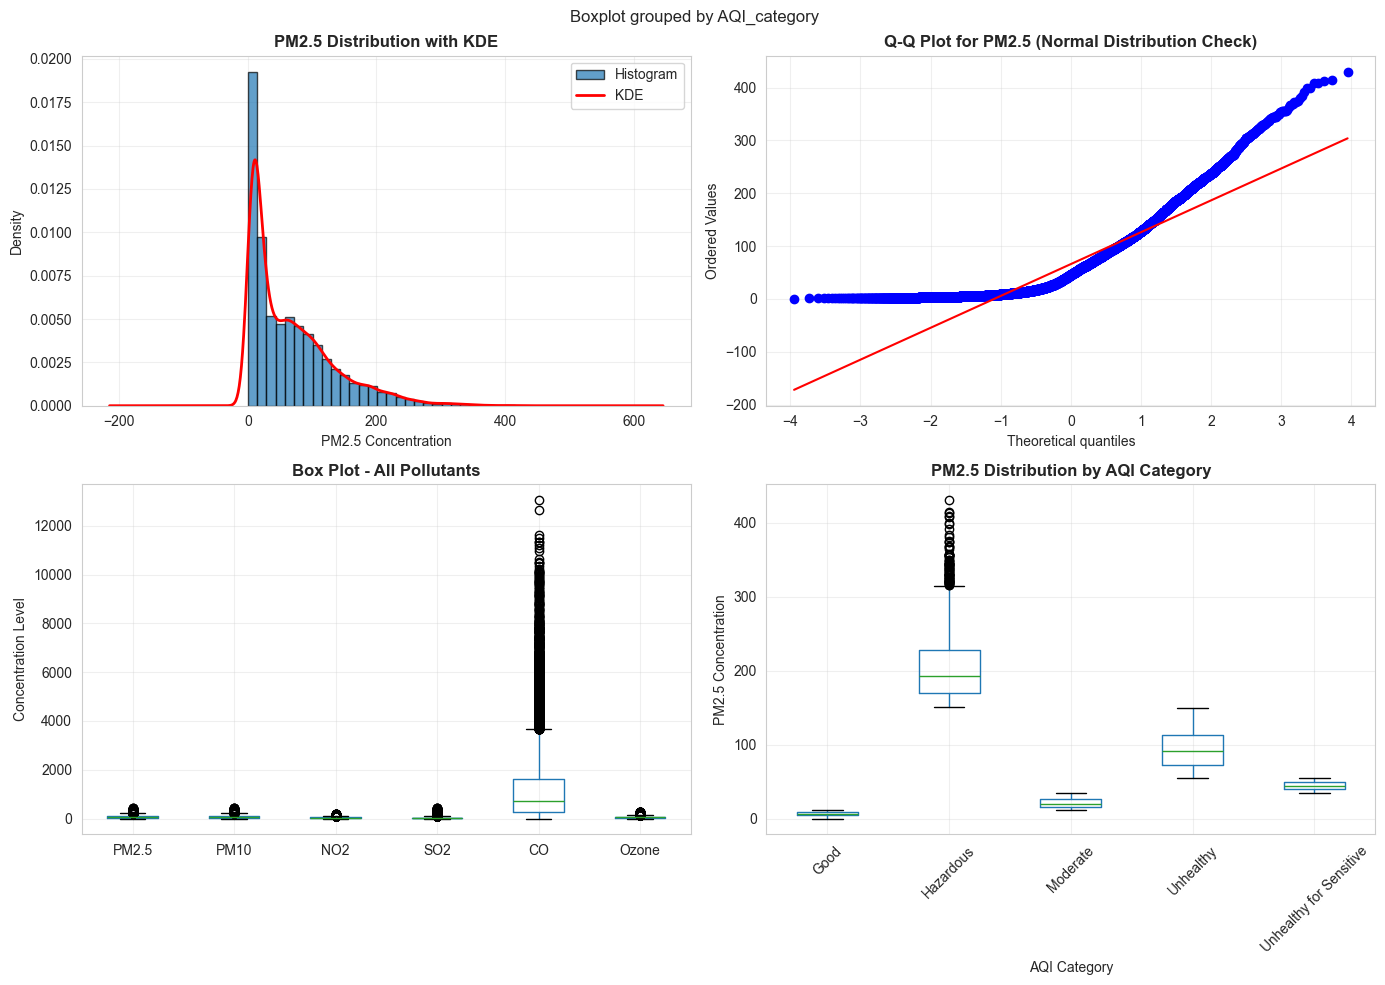


Distribution Analysis:
• If histogram is bell-shaped → Data is likely normal
• If histogram is skewed left/right → Data is not normal
• Q-Q plot: points close to line → Normal distribution
• Q-Q plot: points far from line → Not normal distribution


In [8]:
# Create visualization for PM2.5 distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with KDE for PM2.5
ax1 = axes[0, 0]
pm25_clean = df['PM2.5'].dropna()
ax1.hist(pm25_clean, bins=30, density=True, alpha=0.7, edgecolor='black', label='Histogram')
pm25_clean.plot(kind='kde', ax=ax1, linewidth=2, color='red', label='KDE')
ax1.set_title('PM2.5 Distribution with KDE', fontsize=12, fontweight='bold')
ax1.set_xlabel('PM2.5 Concentration')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot (compares data to normal distribution)
ax2 = axes[0, 1]
stats.probplot(pm25_clean, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot for PM2.5 (Normal Distribution Check)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Box plot for all pollutants
ax3 = axes[1, 0]
df[pollutants].boxplot(ax=ax3)
ax3.set_title('Box Plot - All Pollutants', fontsize=12, fontweight='bold')
ax3.set_ylabel('Concentration Level')
ax3.grid(True, alpha=0.3)

# 4. Distribution by AQI Category
ax4 = axes[1, 1]
df.boxplot(column='PM2.5', by='AQI_category', ax=ax4)
ax4.set_title('PM2.5 Distribution by AQI Category', fontsize=12, fontweight='bold')
ax4.set_xlabel('AQI Category')
ax4.set_ylabel('PM2.5 Concentration')
plt.sca(ax4)
plt.xticks(rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistribution Analysis:")
print("="*50)
print("• If histogram is bell-shaped → Data is likely normal")
print("• If histogram is skewed left/right → Data is not normal")
print("• Q-Q plot: points close to line → Normal distribution")
print("• Q-Q plot: points far from line → Not normal distribution")

## Step 8: Summary and Key Findings

This analysis provided insights into the air quality dataset using various statistical tests:

In [9]:
# Create a comprehensive summary report
print("\n" + "="*80)
print("STATISTICAL ANALYSIS SUMMARY REPORT")
print("="*80 + "\n")

print("1. DESCRIPTIVE STATISTICS")
print("-" * 50)
print("The describe() function gave us:")
print("   • Mean: Average value of each pollutant")
print("   • Std: How spread out values are")
print("   • Min/Max: Range of observed values")
print("   • Quartiles: How data is distributed")
print()

print("2. NORMALITY TEST (Shapiro-Wilk)")
print("-" * 50)
print("   Tested if PM2.5 follows a normal distribution")
print(f"   Result: ", end="")
if p_value > 0.05:
    print("Data appears NORMAL")
else:
    print("Data is NOT NORMAL")
print(f"   P-value: {p_value:.6f}")
print()

print("3. Z-TEST (Group Comparison)")
print("-" * 50)
print(f"   Compared PM2.5 levels between '{group1_name}' and '{group2_name}'")
print(f"   Result: ", end="")
if p_value_ztest <= 0.05:
    print("SIGNIFICANT DIFFERENCE found")
else:
    print("NO significant difference")
print(f"   P-value: {p_value_ztest:.6f}")
print()

print("4. CHI-SQUARE TEST (Association)")
print("-" * 50)
print("   Tested if city and AQI category are related")
print(f"   Result: ", end="")
if p_value_chi <= 0.05:
    print("SIGNIFICANT RELATIONSHIP found")
else:
    print("NO significant relationship")
print(f"   P-value: {p_value_chi:.6f}")
print()

print("5. MULTICOLLINEARITY (VIF)")
print("-" * 50)
print("   Checked for correlations between pollutants:")
for idx, row in vif_results.iterrows():
    print(f"   • {row['Feature']:12} - VIF: {row['VIF']:.3f}")
print()

print("6. DISTRIBUTION SHAPE")
print("-" * 50)
skewness = df['PM2.5'].skew()
print(f"   PM2.5 Skewness: {skewness:.3f}")
if abs(skewness) < 0.5:
    print("   → Approximately symmetric (normal-like)")
elif skewness > 0:
    print("   → Right-skewed (positively skewed)")
else:
    print("   → Left-skewed (negatively skewed)")
print()

print("="*80)
print("Analysis complete! Check the visualizations above for more insights.")
print("="*80)


STATISTICAL ANALYSIS SUMMARY REPORT

1. DESCRIPTIVE STATISTICS
--------------------------------------------------
The describe() function gave us:
   • Mean: Average value of each pollutant
   • Std: How spread out values are
   • Min/Max: Range of observed values
   • Quartiles: How data is distributed

2. NORMALITY TEST (Shapiro-Wilk)
--------------------------------------------------
   Tested if PM2.5 follows a normal distribution
   Result: Data is NOT NORMAL
   P-value: 0.000000

3. Z-TEST (Group Comparison)
--------------------------------------------------
   Compared PM2.5 levels between 'Unhealthy' and 'Good'
   Result: SIGNIFICANT DIFFERENCE found
   P-value: 0.000000

4. CHI-SQUARE TEST (Association)
--------------------------------------------------
   Tested if city and AQI category are related
   Result: SIGNIFICANT RELATIONSHIP found
   P-value: 0.000000

5. MULTICOLLINEARITY (VIF)
--------------------------------------------------
   Checked for correlations between p